# 05 - Demand Analysis

Answers: when is demand highest, which stations/areas see the most demand, and are there consistently overloaded stations?

In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '../python')
import analysis as an

df = pd.read_csv('../data/processed/ev_charging_features.csv')
demand = an.demand_analysis(df)
demand['by_hour'].sort_values('sessions', ascending=False).head(3)

,hour,sessions
19,19,6967
18,18,6344
20,20,6134


## 1. When is demand highest? (hour + day-of-week heatmap)

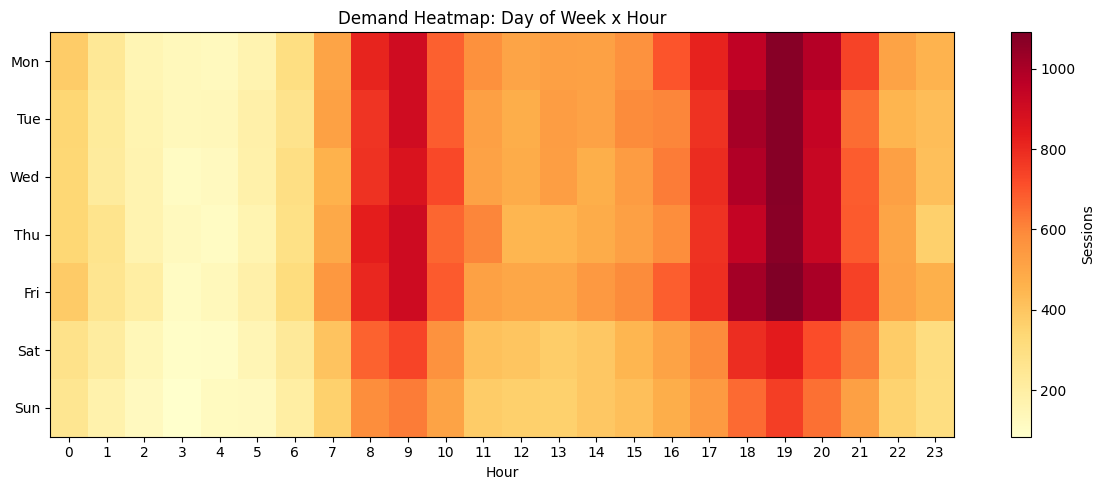

In [2]:
heat = df.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
heat.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plt.figure(figsize=(12,5))
plt.imshow(heat, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Sessions')
plt.yticks(range(7), heat.index); plt.xticks(range(24), heat.columns)
plt.xlabel('Hour'); plt.title('Demand Heatmap: Day of Week x Hour'); plt.tight_layout(); plt.show()

## 2. Which stations see the most demand?

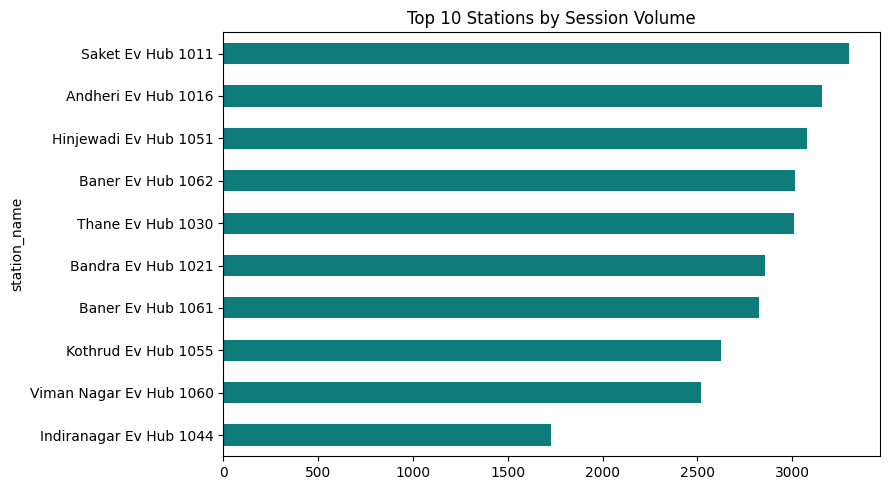

In [3]:
top_stations = demand['by_station'].head(10)
top_stations.set_index('station_name')['sessions'].plot(kind='barh', figsize=(9,5), color='#0E7C7B')
plt.gca().invert_yaxis(); plt.title('Top 10 Stations by Session Volume'); plt.tight_layout(); plt.show()

## 3. Which locations (cities) have the highest demand?

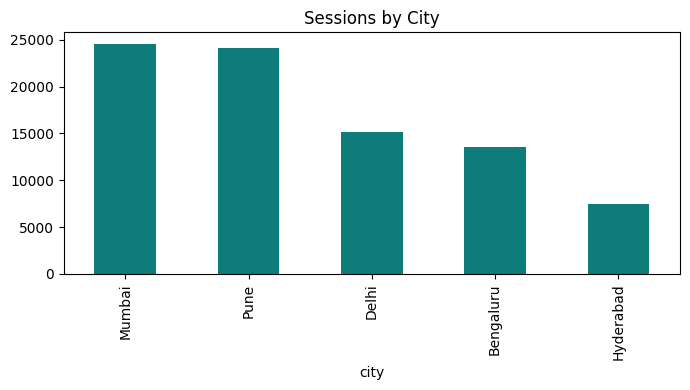

In [4]:
demand['by_city'].set_index('city')['sessions'].plot(kind='bar', figsize=(7,4), color='#0E7C7B', title='Sessions by City')
plt.tight_layout(); plt.show()

## 4. Weekday vs weekend differences

In [5]:
wkc = demand['weekend_vs_weekday'].copy()
wkc['label'] = wkc['is_weekend'].map({True:'Weekend day (avg)', False:'Weekday (avg)'})
wkc['avg_per_day'] = wkc.apply(lambda r: r['sessions']/2 if r['is_weekend'] else r['sessions']/5, axis=1)
print(wkc[['label','avg_per_day']])

               label  avg_per_day
0      Weekday (avg)      13044.6
1  Weekend day (avg)       9839.5


## 5. Stations that are consistently overloaded
A station is flagged 'consistently high demand' if it ranks in the top-10 busiest stations on more than half of all days in the dataset (matches SQL query #14 in `sql/demand_analysis.sql`).

In [6]:
daily_station = df.groupby(['date','station_id']).size().reset_index(name='sessions')
daily_station['daily_rank'] = daily_station.groupby('date')['sessions'].rank(ascending=False, method='min')
top10_days = daily_station[daily_station['daily_rank'] <= 10].groupby('station_id').size()
total_days = df['date'].nunique()
consistent = top10_days[top10_days > 0.5 * total_days].sort_values(ascending=False)
names = df.drop_duplicates('station_id').set_index('station_id')['station_name']
pd.DataFrame({'days_in_top10': consistent, 'pct_of_days': (consistent/total_days*100).round(1)}).join(names).sort_values('days_in_top10', ascending=False)

,days_in_top10,pct_of_days,station_name
station_id,,,
ST1011,316,86.3,Saket Ev Hub 1011
ST1016,314,85.8,Andheri Ev Hub 1016
ST1051,309,84.4,Hinjewadi Ev Hub 1051
ST1062,305,83.3,Baner Ev Hub 1062
ST1030,302,82.5,Thane Ev Hub 1030
ST1021,291,79.5,Bandra Ev Hub 1021
ST1061,286,78.1,Baner Ev Hub 1061
ST1055,264,72.1,Kothrud Ev Hub 1055
ST1060,241,65.8,Viman Nagar Ev Hub 1060
